# Business Understanding

## Project Domain

Proyek ini berada dalam domain healthcare insurance analytics. Fokus utamanya adalah memanfaatkan data pasien (seperti usia, BMI, status merokok, dll.) untuk memprediksi biaya asuransi medis menggunakan pendekatan machine learning, khususnya deep learning.

## Problem Statements

Perusahaan asuransi kesulitan dalam memperkirakan biaya premi asuransi yang akurat untuk setiap individu. Ketidaktepatan estimasi dapat menyebabkan kerugian finansial (jika premi terlalu rendah) atau hilangnya pelanggan (jika premi terlalu tinggi). Oleh karena itu, dibutuhkan model prediktif yang mampu mengestimasi biaya asuransi medis secara akurat berdasarkan data pelanggan.

## Goals

Membangun model deep learning (MLP Neural Network) untuk memprediksi biaya asuransi individu secara akurat.

Melakukan eksplorasi data untuk memahami faktor-faktor yang memengaruhi biaya asuransi (misalnya: status merokok, BMI, usia).

Mengimplementasikan pipeline machine learning end-to-end, termasuk preprocessing, training, evaluasi, hingga deployment (model dalam format TFLite dan scaler disimpan).

Memberikan simulasi prediksi biaya untuk data pasien baru.

## Solution Statements

Solusi yang diusulkan adalah membangun model prediktif berbasis deep learning dengan arsitektur multilayer perceptron (MLP) untuk memodelkan hubungan kompleks antara fitur-fitur seperti usia, BMI, jumlah anak, status merokok, jenis kelamin, dan wilayah dengan biaya asuransi. Model ini:

Dilatih menggunakan data historis pelanggan asuransi.

Menggunakan teknik feature engineering seperti interaksi antara usia dan BMI serta klasifikasi obesitas.

Dikonversi ke format TFLite untuk kemudahan integrasi ke aplikasi mobile atau edge computing.

Didukung dengan visualisasi data untuk membantu dalam pemahaman bisnis dan validasi model.

# Data Understanding

## Import data dari kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hargriv","key":"b411c50fba78d05d5eda3f001f03b617"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d harishkumardatalab/medical-insurance-price-prediction

Dataset URL: https://www.kaggle.com/datasets/harishkumardatalab/medical-insurance-price-prediction
License(s): CC0-1.0


In [ ]:
!mkdir medical-insurance-price-prediction
!unzip medical-insurance-price-prediction.zip -d medical-insurance-price-prediction
!ls medical-insurance-price-prediction

Archive:  medical-insurance-price-prediction.zip
  inflating: medical-insurance-price-prediction/Medical_insurance.csv  
Medical_insurance.csv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [ ]:
df = pd.read_csv('medical-insurance-price-prediction/Medical_insurance.csv')
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [ ]:
  df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory Data Analysis

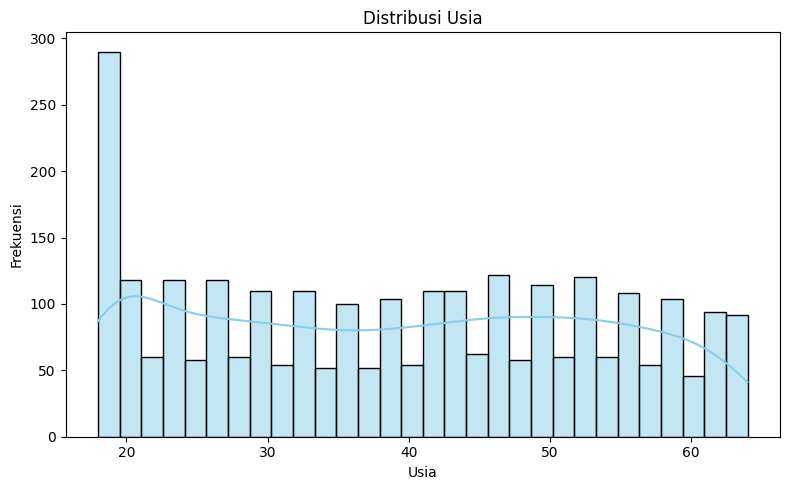

In [ ]:
# 1. Distribusi Usia
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Usia')
plt.xlabel('Usia')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

<ipython-input-12-d5f4286f340b>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')


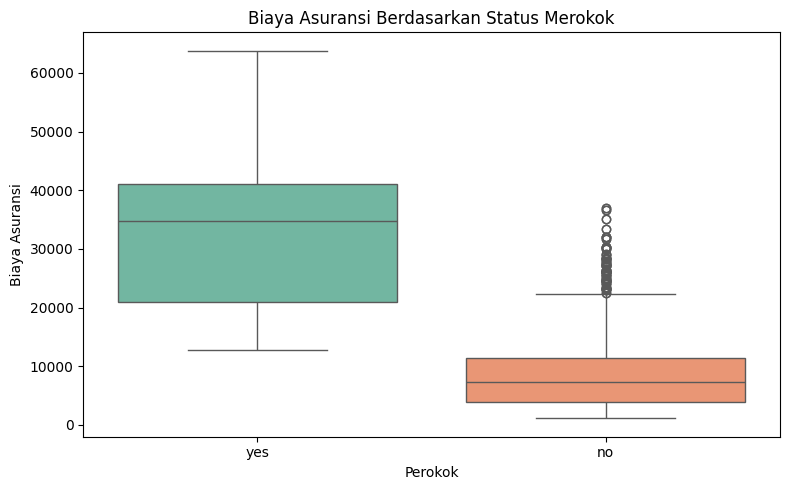

In [ ]:
# 2. Boxplot Biaya Asuransi Berdasarkan Status Merokok
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df, palette='Set2')
plt.title('Biaya Asuransi Berdasarkan Status Merokok')
plt.xlabel('Perokok')
plt.ylabel('Biaya Asuransi')
plt.tight_layout()
plt.show()

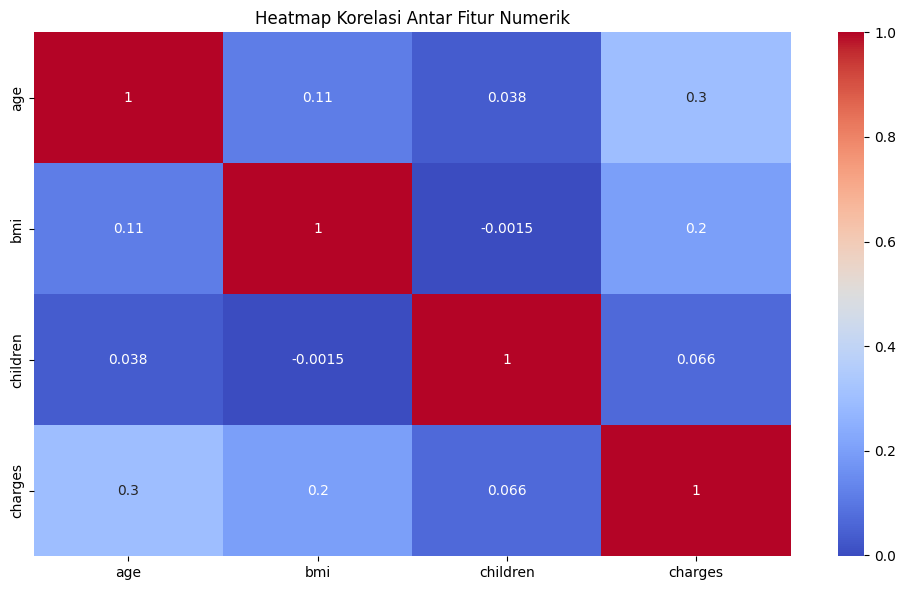

In [ ]:
# 3. Korelasi Antar Fitur Numerik
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.tight_layout()
plt.show()

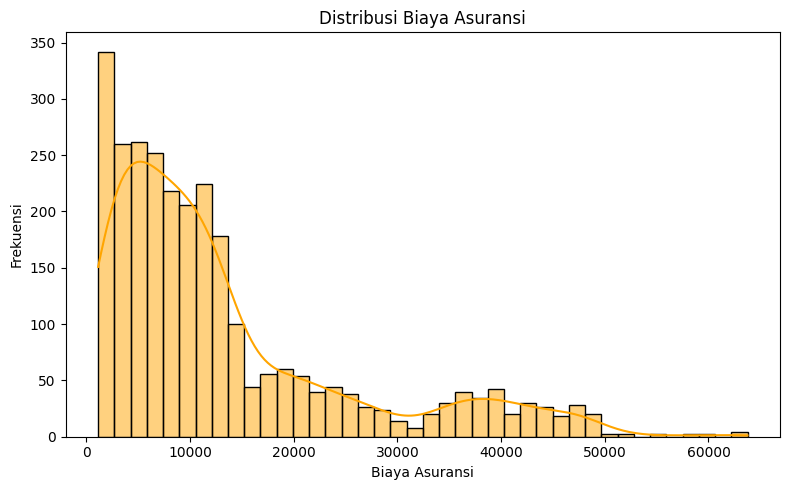

In [ ]:
# 4. Distribusi Biaya Asuransi
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=40, kde=True, color='orange')
plt.title('Distribusi Biaya Asuransi')
plt.xlabel('Biaya Asuransi')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

<ipython-input-15-818f5fa3678f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='region', y='charges', data=df, estimator=np.mean, palette='pastel')


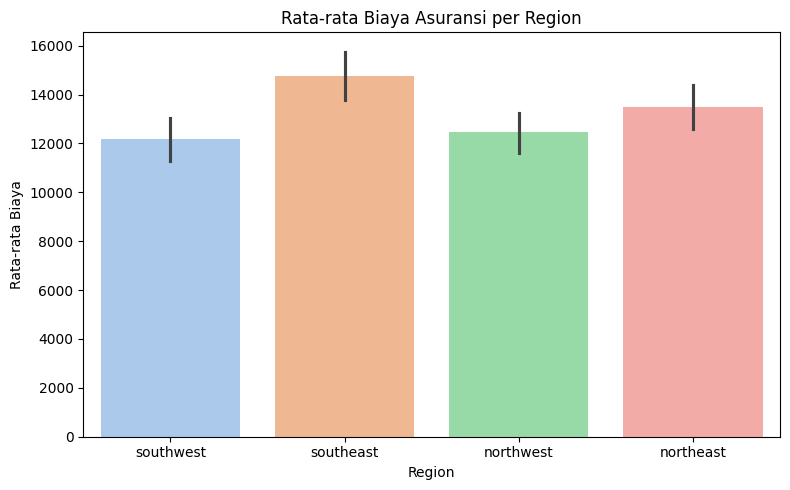

In [ ]:
# 5. Rata-rata Biaya Asuransi Berdasarkan Region
plt.figure(figsize=(8, 5))
sns.barplot(x='region', y='charges', data=df, estimator=np.mean, palette='pastel')
plt.title('Rata-rata Biaya Asuransi per Region')
plt.xlabel('Region')
plt.ylabel('Rata-rata Biaya')
plt.tight_layout()
plt.show()

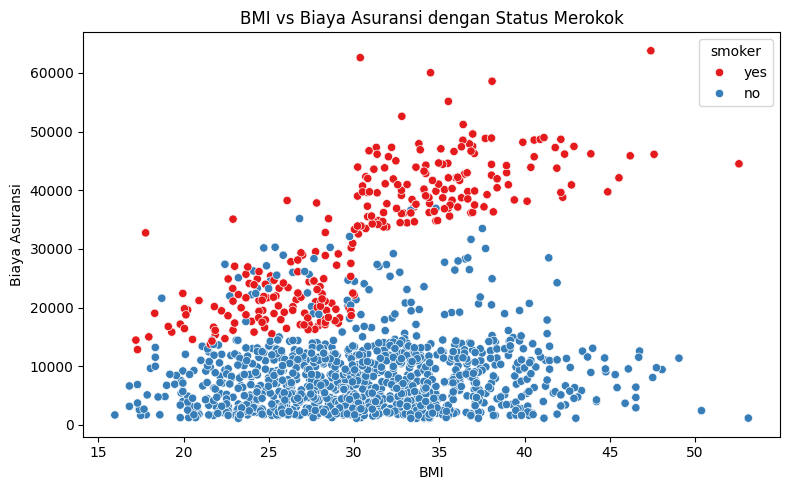

In [ ]:
# 6. Scatterplot BMI vs Biaya Asuransi
plt.figure(figsize=(8, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='Set1')
plt.title('BMI vs Biaya Asuransi dengan Status Merokok')
plt.xlabel('BMI')
plt.ylabel('Biaya Asuransi')
plt.tight_layout()
plt.show()

# Data Preparation

In [ ]:
# Tambahkan fitur interaksi
df['bmi_age_interaction'] = df['bmi'] * df['age']
df['is_obese'] = (df['bmi'] > 30).astype(int)

In [ ]:
# Hapus outlier pada charges (opsional, tapi membantu)
df = df[df['charges'] < df['charges'].quantile(0.99)]

In [ ]:
# Encode data kategorikal
categorical_cols = ['sex', 'smoker', 'region']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
# Feature dan Target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

In [ ]:
# Normalisasi fitur numerik
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [ ]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Ubah ke tipe float32 untuk TensorFlow
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

# Modeling

In [ ]:
# MLP Neural Network
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error', metrics=['mae'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 291420960.0000 - mae: 12694.9355 - val_loss: 325824640.0000 - val_mae: 13275.4648
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 281256416.0000 - mae: 12437.4873 - val_loss: 319516128.0000 - val_mae: 13063.1240
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 290297568.0000 - mae: 12521.6309 - val_loss: 274792032.0000 - val_mae: 11482.1299
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 227051136.0000 - mae: 10339.6172 - val_loss: 160048832.0000 - val_mae: 8034.3926
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 116590208.0000 - mae: 7343.8945 - val_loss: 113655648.0000 - val_mae: 8405.4658
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 98130248.0000 - mae: 7774.0850 - val_loss: 107845744.0000 - val_mae: 8312.1152
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94377480.0000 - mae: 7767.1865 - val_loss: 102845256.0000 - val_mae: 8077.2002
Epoch 8/100
69/69 ━━━

# Evaluation

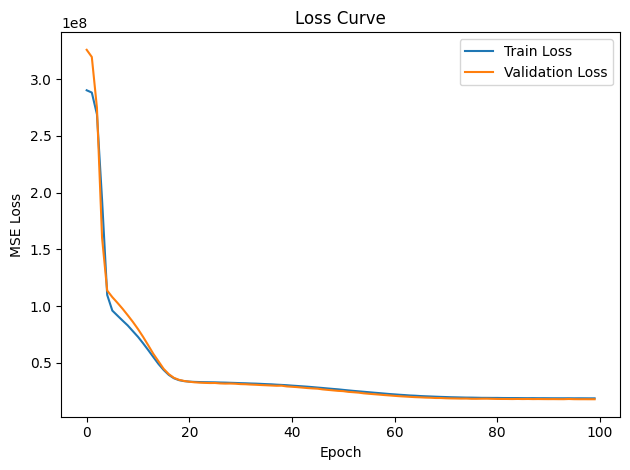

In [ ]:
# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# R2 Score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'MAE: {mae:.2f}')

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
R² Score: 0.8806
MAE: 2265.28


# Deployment

## Model Simulation

In [ ]:
# Simulasi Data Baru untuk Prediksi
new_data = pd.DataFrame({
    'age': [40],
    'bmi': [28.5],
    'children': [2],
    'bmi_age_interaction': [40 * 28.5],
    'is_obese': [0],
    'sex_male': [1],
    'smoker_yes': [0],
    'region_northwest': [0],
    'region_southeast': [1],
    'region_southwest': [0]
})

# Pastikan urutan kolom sesuai dengan model
new_data = new_data[X.columns]  # Gunakan kolom yang sama dari training

# Skala data baru menggunakan scaler yang sudah dilatih
new_data_scaled = pd.DataFrame(scaler.transform(new_data), columns=new_data.columns)
new_data_scaled = new_data_scaled.astype(np.float32)

# Prediksi biaya asuransi
predicted_charge = model.predict(new_data_scaled)
print(f"Biaya Asuransi yang Diprediksi: ${predicted_charge[0][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Biaya Asuransi yang Diprediksi: $9095.74


## Save Model

In [ ]:
# Konversi model ke format TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.experimental_enable_resource_variables = True
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

# Simpan model TFLite
with open('insurance_cost_prediction_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Model berhasil dikonversi dan disimpan sebagai 'insurance_cost_prediction_model.tflite'")


Saved artifact at '/tmp/tmpa7c_3b6e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 10), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137548453306512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453307664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453305936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453304400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453308240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453304592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453308624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453307472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453308048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137548453309776: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model berhasil dikonver

In [ ]:
import pickle

# Simpan scaler ke file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Scaler berhasil disimpan sebagai 'scaler.pkl'")

✅ Scaler berhasil disimpan sebagai 'scaler.pkl'


In [ ]:
# prompt: import yang digunakan version berapa aja?

import pandas as pd
import numpy as np
import sklearn
import tensorflow as tf
import seaborn as sns
import matplotlib
import pickle

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("scikit-learn version:", sklearn.__version__)
print("tensorflow version:", tf.__version__)
print("seaborn version:", sns.__version__)
print("matplotlib version:", matplotlib.__version__)
print("pickle version:", pickle.format_version)


pandas version: 2.2.2
numpy version: 2.0.2
scikit-learn version: 1.6.1
tensorflow version: 2.18.0
seaborn version: 0.13.2
matplotlib version: 3.10.0
pickle version: 4.0
